In [1]:
import os
import json
from glob import glob
from collections import defaultdict

import numpy as np
from PIL import Image, UnidentifiedImageError

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

import matplotlib.pyplot as plt

IMG_SIZE      = (300, 300)
BATCH_SIZE    = 32
EPOCHS_PHASE1 = 30
EPOCHS_PHASE2 = 60
LEARNING_RATE = 1e-4

DINO_FOLDER    = "dataset/dinosaur"
MODEL_PATH     = "models/stage2_dino_species.keras"
CLASS_MAP_PATH = "models/stage2_dino_classes.json"

In [2]:
%pip install tensorflow numpy pillow scikit-learn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
def get_base_class(folder_name):
    return folder_name.split("_")[0]

grouped_folders = defaultdict(list)

for sub in os.listdir(DINO_FOLDER):
    full_path = os.path.join(DINO_FOLDER, sub)
    if os.path.isdir(full_path):
        base_class = get_base_class(sub)
        grouped_folders[base_class].append(full_path)

class_names  = sorted(grouped_folders.keys())
class_to_idx = {cls: i for i, cls in enumerate(class_names)}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

In [4]:
print(f"Унікальних класів: {len(class_names)}")
print()
for cls, paths in sorted(grouped_folders.items()):
    print(f"  {cls}: {len(paths)} папки")

Унікальних класів: 117

  Abelisaurus: 1 папки
  Acrocanthosaurus: 1 папки
  Alamosaurus: 1 папки
  Allosaurus: 2 папки
  Anchiornis: 1 папки
  Ankylosaurus: 5 папки
  Apatosaurus: 2 папки
  Archaeopteryx: 2 папки
  Argentinosaurus: 2 папки
  Atrociraptor: 1 папки
  Austroraptor: 1 папки
  Barosaurus: 2 папки
  Baryonyx: 2 папки
  Brachiosaurus: 4 папки
  Buitreraptor: 1 папки
  Camarasaurus: 1 папки
  Camptosaurus: 1 папки
  Carcharodontosaurus: 1 папки
  Carnotaurus: 2 папки
  Ceratosaurus: 2 папки
  Cetiosaurus: 1 папки
  Chasmosaurus: 1 папки
  Coelophysis: 1 папки
  Compsognathus: 4 папки
  Corythosaurus: 3 папки
  Deinonychus: 1 папки
  Dilophosaurus: 4 папки
  Dimetrodon: 1 папки
  Dimorphodon: 3 папки
  Diplodocus: 2 папки
  Dreadnoughtus: 1 папки
  Dryosaurus: 1 папки
  Edmontosaurus: 1 папки
  Emausaurus: 1 папки
  Eoraptor: 1 папки
  Epidexipteryx: 1 папки
  Euoplocephalus: 1 папки
  Europasaurus: 1 папки
  Gallimimus: 4 папки
  Giganotosaurus: 2 папки
  Haplocanthosaurus: 1

In [5]:
os.makedirs("models", exist_ok=True)
with open(CLASS_MAP_PATH, "w", encoding="utf-8") as f:
    json.dump(idx_to_class, f, indent=2, ensure_ascii=False)

In [6]:
VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def get_images_from_folder(folder):
    paths = glob(f"{folder}/**/*.*", recursive=True)
    return [p for p in paths if os.path.splitext(p)[1].lower() in VALID_EXT]

train_paths = []  # list of (image_path, label)
val_paths   = []
test_paths  = []

for cls, folders in grouped_folders.items():
    label = class_to_idx[cls]

    if len(folders) == 1:
        # image-level split — щоб клас потрапив і в val
        images = get_images_from_folder(folders[0])
        if len(images) < 2:
            train_paths += [(p, label) for p in images]
        else:
            tr_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)
            train_paths += [(p, label) for p in tr_imgs]
            val_paths   += [(p, label) for p in val_imgs]
        continue

    train_f, temp_f = train_test_split(folders, test_size=0.3, random_state=42)

    if len(temp_f) > 1:
        val_f, test_f = train_test_split(temp_f, test_size=0.5, random_state=42)
    else:
        val_f  = temp_f
        test_f = []

    for f in train_f:
        train_paths += [(p, label) for p in get_images_from_folder(f)]
    for f in val_f:
        val_paths   += [(p, label) for p in get_images_from_folder(f)]
    for f in test_f:
        test_paths  += [(p, label) for p in get_images_from_folder(f)]

print(f"Train: {len(train_paths)} зображень")
print(f"Val:   {len(val_paths)} зображень")
print(f"Test:  {len(test_paths)} зображень")

Train: 6541 зображень
Val:   4819 зображень
Test:  1261 зображень


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def prefilter_paths(paths_labels):
    """Пробує реально декодувати кожне зображення через TF і відкидає ті, що падають."""
    valid = []
    skipped = 0
    for path, label in paths_labels:
        try:
            raw = tf.io.read_file(path)
            tf.image.decode_image(raw, channels=3, expand_animations=False)
            valid.append((path, label))
        except Exception:
            skipped += 1
    if skipped:
        print(f"  Пропущено {skipped} несумісних зображень")
    return valid

def parse_image(path, label):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    img.set_shape([*IMG_SIZE, 3])
    return img, label

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(40 / 360, fill_mode="nearest"),
    layers.RandomTranslation(0.2, 0.2, fill_mode="nearest"),
    layers.RandomZoom(0.3, fill_mode="nearest"),
    layers.RandomBrightness(0.3),
], name="augmentation")

In [8]:
print("Pre-filtering зображень...")
train_paths = prefilter_paths(train_paths)
val_paths   = prefilter_paths(val_paths)
test_paths  = prefilter_paths(test_paths)

train_img_paths = [p for p, _ in train_paths]
train_labels    = [l for _, l in train_paths]
val_img_paths   = [p for p, _ in val_paths]
val_labels      = [l for _, l in val_paths]
test_img_paths  = [p for p, _ in test_paths]
test_labels     = [l for _, l in test_paths]

y_train = np.array(train_labels, dtype=np.int32)

print(f"\nГотово (шляхи, без RAM):")
print(f"  Train: {len(train_img_paths)}")
print(f"  Val:   {len(val_img_paths)}")
print(f"  Test:  {len(test_img_paths)}")

Pre-filtering зображень...
  Пропущено 53 несумісних зображень
  Пропущено 10 несумісних зображень

Готово (шляхи, без RAM):
  Train: 6488
  Val:   4809
  Test:  1261


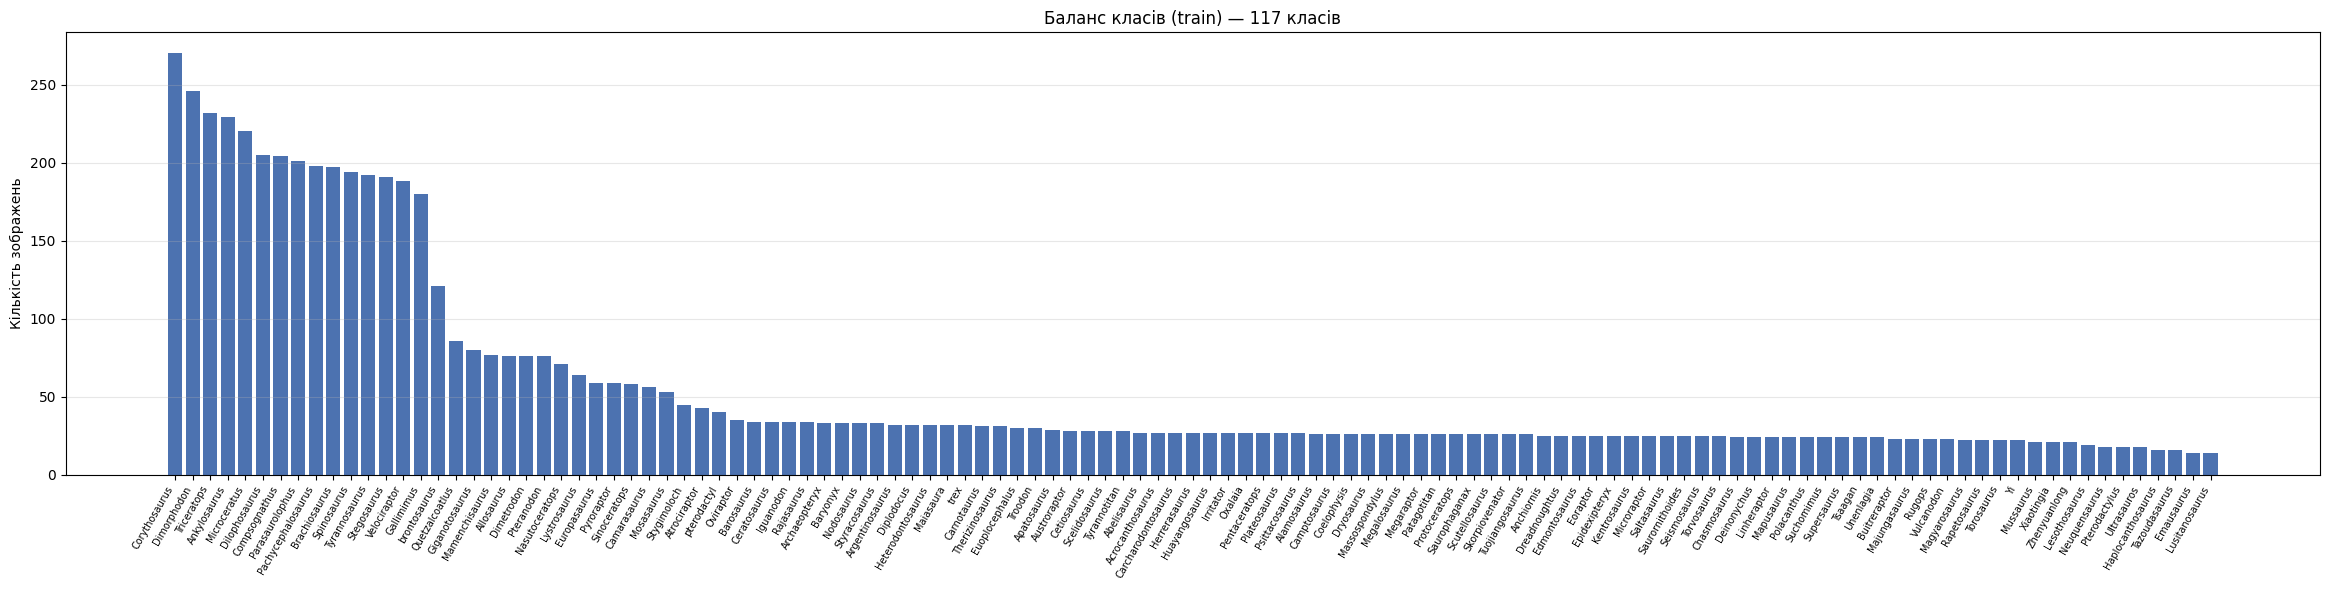

In [9]:
class_counts = {cls: 0 for cls in class_to_idx.keys()}
for label in y_train:
    class_counts[idx_to_class[label]] += 1

sorted_items = sorted(class_counts.items(), key=lambda x: -x[1])
bar_labels = [item[0] for item in sorted_items]
bar_counts = [item[1] for item in sorted_items]

fig, ax = plt.subplots(figsize=(max(20, len(bar_labels) * 0.2), 6))
ax.bar(range(len(bar_labels)), bar_counts, color="#4C72B0")
ax.set_xticks(range(len(bar_labels)))
ax.set_xticklabels(bar_labels, rotation=60, ha="right", fontsize=7)
ax.set_ylabel("Кількість зображень")
ax.set_title(f"Баланс класів (train) — {len(bar_labels)} класів")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
def augment_and_preprocess(img, label):
    img = augmentation(img, training=True)
    img = preprocess_input(img)
    return img, label

def preprocess_only(img, label):
    img = preprocess_input(img)
    return img, label

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_img_paths, train_labels))
    .shuffle(len(train_img_paths), reshuffle_each_iteration=True)
    .map(parse_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(augment_and_preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_img_paths, val_labels))
    .map(parse_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(preprocess_only, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_img_paths, test_labels))
    .map(parse_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .map(preprocess_only, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
) if test_img_paths else None

print("tf.data pipeline готовий")

tf.data pipeline готовий


In [11]:
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [13]:
base_model = EfficientNetV2S(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False

feat_dim = base_model.output_shape[-1]

# Define the head ONCE as a standalone model
feat_inp = layers.Input(shape=(feat_dim,), name="feat_input")
hx = layers.BatchNormalization()(feat_inp)
hx = layers.Dense(1024, activation="relu")(hx)
hx = layers.Dropout(0.5)(hx)
hx = layers.Dense(512, activation="relu")(hx)
hx = layers.Dropout(0.3)(hx)
hx = layers.Dense(len(class_names), activation="softmax")(hx)
head_model = models.Model(inputs=feat_inp, outputs=hx, name="head_model")

# Full model = base -> GAP -> head (weights shared with head_model)
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
outputs = head_model(x)
model = models.Model(inputs=base_model.input, outputs=outputs, name="full_model")

# Feature extractor: base -> GAP (for caching Phase 1)
feat_extractor = models.Model(
    inputs=base_model.input,
    outputs=x,
    name="feat_extractor"
)

print(f"Класів: {len(class_names)}")
print(f"Параметрів базової моделі: {base_model.count_params():,}")
print(f"Параметрів всього:         {model.count_params():,}")
print(f"Розмір фіч-вектора:        {feat_dim}")

Класів: 117
Параметрів базової моделі: 20,331,360
Параметрів всього:         22,233,045
Розмір фіч-вектора:        1280


In [14]:
head_model.compile(
    optimizer=optimizers.Adam(LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

head_model.summary()

Model: "head_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ feat_input (InputLayer)         │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,311,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 117)            │        60,021 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,901,685 (7.25 MB)

 Trainable params: 1,899,125 (7.24 MB)

 Non-trainable params: 2,560 (10.00 KB)

In [15]:
AUG_ROUNDS = 3  # кількість аугментованих проходів базою (різні аугментації)

print(f"Кешування фіч ({AUG_ROUNDS} проходи через базову модель)...")
train_feats, train_lbls = [], []
for r in range(AUG_ROUNDS):
    for imgs, lbls in train_ds:
        train_feats.append(feat_extractor(imgs, training=False).numpy())
        train_lbls.append(lbls.numpy())
    print(f"  Раунд {r + 1}/{AUG_ROUNDS} готово")

val_feats, val_lbls = [], []
for imgs, lbls in val_ds:
    val_feats.append(feat_extractor(imgs, training=False).numpy())
    val_lbls.append(lbls.numpy())

X_feat     = np.concatenate(train_feats)
y_feat     = np.concatenate(train_lbls)
X_feat_val = np.concatenate(val_feats)
y_feat_val = np.concatenate(val_lbls)

feat_train_ds = (
    tf.data.Dataset.from_tensor_slices((X_feat, y_feat))
    .shuffle(len(X_feat))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
feat_val_ds = (
    tf.data.Dataset.from_tensor_slices((X_feat_val, y_feat_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"Train фічі: {X_feat.shape} (~{X_feat.nbytes / 1024**2:.0f} MB)")
print(f"Val   фічі: {X_feat_val.shape}")

Кешування фіч (3 проходи через базову модель)...
  Раунд 1/3 готово
  Раунд 2/3 готово
  Раунд 3/3 готово
Train фічі: (19464, 1280) (~95 MB)
Val   фічі: (4809, 1280)


In [16]:
callbacks_phase1 = [
    EarlyStopping(monitor="val_loss", patience=10, min_delta=0.001, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6)
]

callbacks_phase2 = [
    EarlyStopping(monitor="val_loss", patience=12, min_delta=0.001, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-7)
]

In [17]:
print("=== Phase 1: тренуємо head на кешованих фічах ===")
history1 = head_model.fit(
    feat_train_ds,
    validation_data=feat_val_ds,
    epochs=EPOCHS_PHASE1,
    class_weight=class_weights,
    callbacks=callbacks_phase1,
    verbose=2
)

=== Phase 1: тренуємо head на кешованих фічах ===
Epoch 1/30
609/609 - 22s - 37ms/step - accuracy: 0.0424 - loss: 4.7064 - val_accuracy: 0.1185 - val_loss: 4.0896 - learning_rate: 1.0000e-04
Epoch 2/30
609/609 - 19s - 32ms/step - accuracy: 0.1202 - loss: 3.8530 - val_accuracy: 0.2185 - val_loss: 3.4601 - learning_rate: 1.0000e-04
Epoch 3/30
609/609 - 19s - 32ms/step - accuracy: 0.1918 - loss: 3.2853 - val_accuracy: 0.2487 - val_loss: 3.1703 - learning_rate: 1.0000e-04
Epoch 4/30
609/609 - 18s - 30ms/step - accuracy: 0.2469 - loss: 2.8941 - val_accuracy: 0.2905 - val_loss: 2.9865 - learning_rate: 1.0000e-04
Epoch 5/30
609/609 - 18s - 30ms/step - accuracy: 0.2935 - loss: 2.5467 - val_accuracy: 0.3236 - val_loss: 2.7976 - learning_rate: 1.0000e-04
Epoch 6/30
609/609 - 18s - 29ms/step - accuracy: 0.3346 - loss: 2.3094 - val_accuracy: 0.3493 - val_loss: 2.6984 - learning_rate: 1.0000e-04
Epoch 7/30
609/609 - 18s - 29ms/step - accuracy: 0.3742 - loss: 2.0812 - val_accuracy: 0.3566 - val_loss

In [18]:
print("=== Phase 2: fine-tuning (останні 150 шарів розморожені) ===")

for layer in base_model.layers:
    layer.trainable = False
for layer in base_model.layers[-150:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    class_weight=class_weights,
    callbacks=callbacks_phase2,
    verbose=2
)

=== Phase 2: fine-tuning (останні 150 шарів розморожені) ===
Epoch 1/60
203/203 - 2409s - 12s/step - accuracy: 0.3123 - loss: 2.9911 - val_accuracy: 0.3718 - val_loss: 2.7832 - learning_rate: 1.0000e-05
Epoch 2/60
203/203 - 2277s - 11s/step - accuracy: 0.3254 - loss: 2.8412 - val_accuracy: 0.3901 - val_loss: 2.6733 - learning_rate: 1.0000e-05
Epoch 3/60
203/203 - 2237s - 11s/step - accuracy: 0.3426 - loss: 2.6452 - val_accuracy: 0.4047 - val_loss: 2.6072 - learning_rate: 1.0000e-05
Epoch 4/60
203/203 - 2244s - 11s/step - accuracy: 0.3545 - loss: 2.4795 - val_accuracy: 0.4057 - val_loss: 2.5713 - learning_rate: 1.0000e-05
Epoch 5/60
203/203 - 2273s - 11s/step - accuracy: 0.3567 - loss: 2.4380 - val_accuracy: 0.4148 - val_loss: 2.5506 - learning_rate: 1.0000e-05
Epoch 6/60
203/203 - 2262s - 11s/step - accuracy: 0.3705 - loss: 2.3360 - val_accuracy: 0.4234 - val_loss: 2.5047 - learning_rate: 1.0000e-05
Epoch 7/60
203/203 - 2263s - 11s/step - accuracy: 0.3813 - loss: 2.1919 - val_accuracy:

In [19]:
print("\nVal оцінка:")
model.evaluate(val_ds, verbose=2)

if test_ds is not None:
    print("\nTest оцінка:")
    model.evaluate(test_ds, verbose=2)


Val оцінка:
151/151 - 649s - 4s/step - accuracy: 0.5760 - loss: 1.8985

Test оцінка:
40/40 - 176s - 4s/step - accuracy: 0.6796 - loss: 1.0988


In [20]:
model.save(MODEL_PATH)
print(f"Модель збережена: {MODEL_PATH}")
print(f"Class map збережений: {CLASS_MAP_PATH}")

Модель збережена: models/stage2_dino_species.keras
Class map збережений: models/stage2_dino_classes.json
